In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ds_salaries.csv')
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
df.shape

(607, 12)

In [4]:
df.dtypes

Unnamed: 0            int64
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object

In [5]:
df.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [6]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [12]:
# df = df.drop(columns=["Unnamed: 0"]) - Run this to delete the unwanted column
experience_map = {"EN": "Entry", "MI": "Mid","SE": "Senior", "EX": "Executive"}
size_map = {"S": "Small", "M": "Medium", "L": "Large"}
remote_map = {0:"On-site", 50: "Hybrid", 100: "Remote"}

df['experience_level'] = df['experience_level'].map(experience_map)
df['company_size'] = df['company_size'].map(size_map)
df['remote_ratio'] = df['remote_ratio'].map(remote_map)

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,Mid,FT,Data Scientist,70000,EUR,79833,DE,On-site,DE,Large
1,2020,Senior,FT,Machine Learning Scientist,260000,USD,260000,JP,On-site,JP,Small
2,2020,Senior,FT,Big Data Engineer,85000,GBP,109024,GB,Hybrid,GB,Medium
3,2020,Mid,FT,Product Data Analyst,20000,USD,20000,HN,On-site,HN,Small
4,2020,Senior,FT,Machine Learning Engineer,150000,USD,150000,US,Hybrid,US,Large


In [13]:
# Cell 7 — Set a clean visual style once for all charts
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

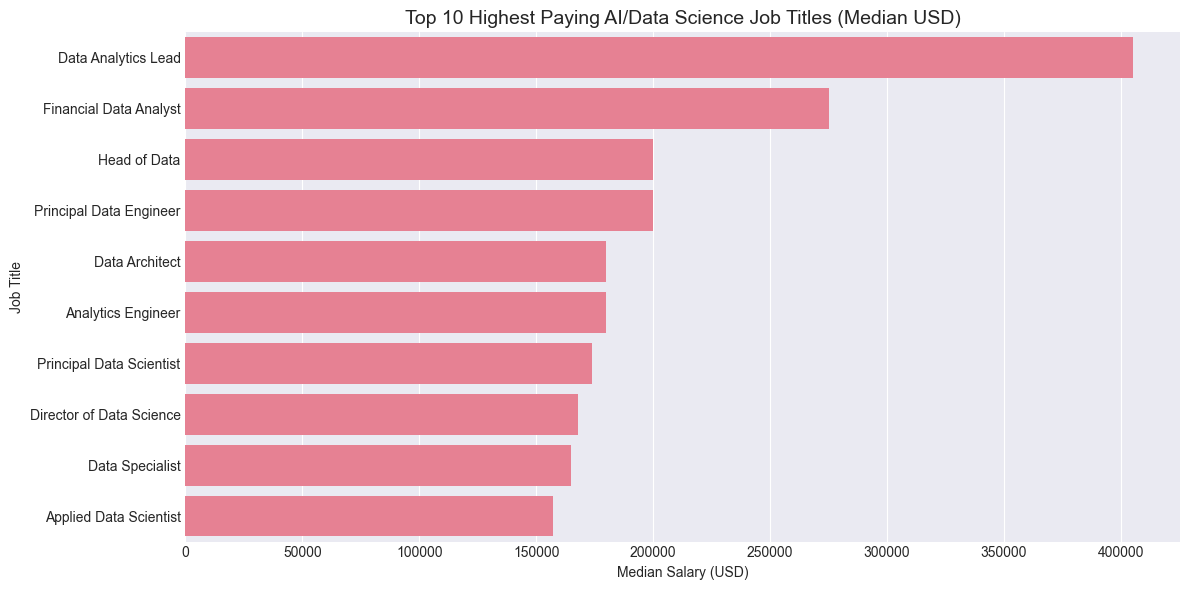

In [14]:
# Cell 8 — Top 10 highest paying job titles
plt.figure(figsize=(12, 6))

top_titles = (df.groupby("job_title")["salary_in_usd"]
                .median()
                .sort_values(ascending=False)
                .head(10))

sns.barplot(x=top_titles.values, y=top_titles.index)
plt.title("Top 10 Highest Paying AI/Data Science Job Titles (Median USD)", fontsize=14)
plt.xlabel("Median Salary (USD)")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

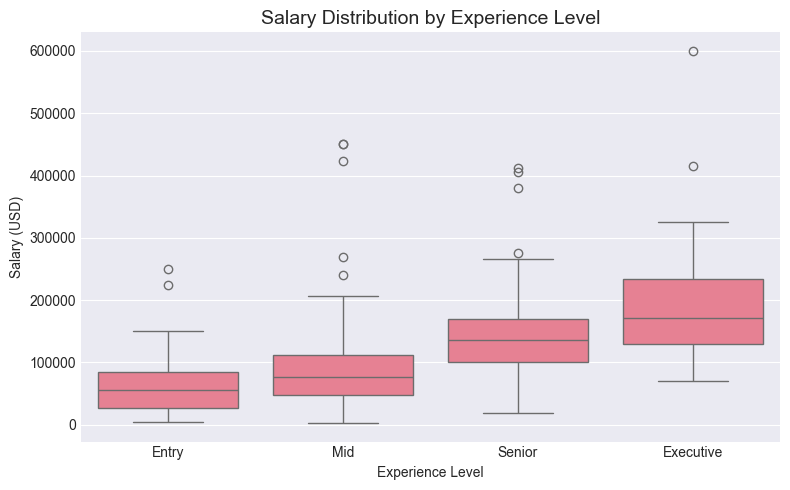

In [15]:
# Cell 9 — Salary by experience level
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="experience_level", y="salary_in_usd",
            order=["Entry", "Mid", "Senior", "Executive"])
plt.title("Salary Distribution by Experience Level", fontsize=14)
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")
plt.tight_layout()
plt.show()

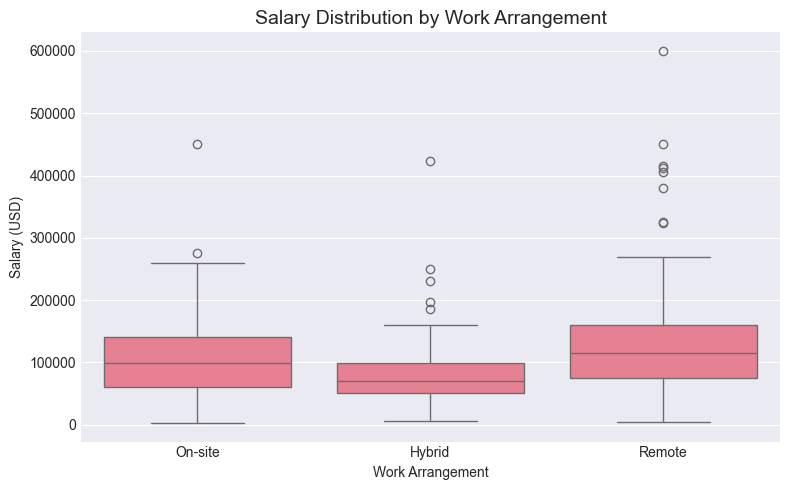

In [16]:
# Cell 10 — Remote vs On-site vs Hybrid salaries
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="remote_ratio", y="salary_in_usd",
            order=["On-site", "Hybrid", "Remote"])
plt.title("Salary Distribution by Work Arrangement", fontsize=14)
plt.xlabel("Work Arrangement")
plt.ylabel("Salary (USD)")
plt.tight_layout()
plt.show()

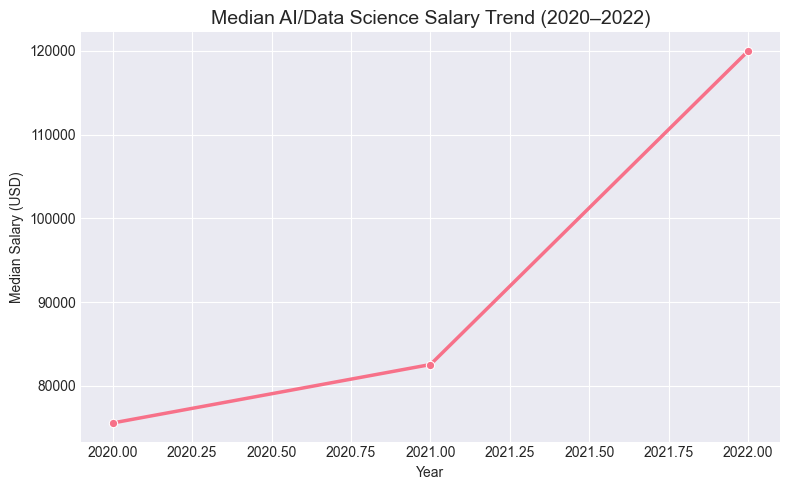

In [17]:
# Cell 11 — Salary trend over years
plt.figure(figsize=(8, 5))

yearly = df.groupby("work_year")["salary_in_usd"].median().reset_index()

sns.lineplot(data=yearly, x="work_year", y="salary_in_usd", marker="o", linewidth=2.5)
plt.title("Median AI/Data Science Salary Trend (2020–2022)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Median Salary (USD)")
plt.tight_layout()
plt.show()

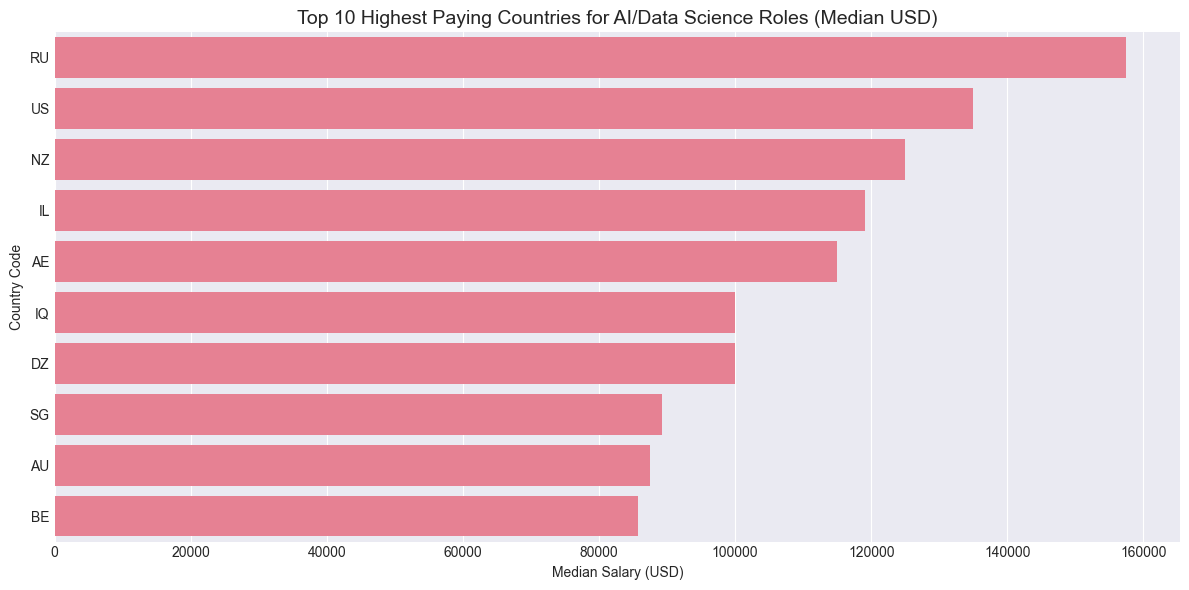

In [18]:
# Cell 12 — Top 10 highest paying countries
plt.figure(figsize=(12, 6))

top_countries = (df.groupby("company_location")["salary_in_usd"]
                   .median()
                   .sort_values(ascending=False)
                   .head(10))

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Highest Paying Countries for AI/Data Science Roles (Median USD)", fontsize=14)
plt.xlabel("Median Salary (USD)")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()

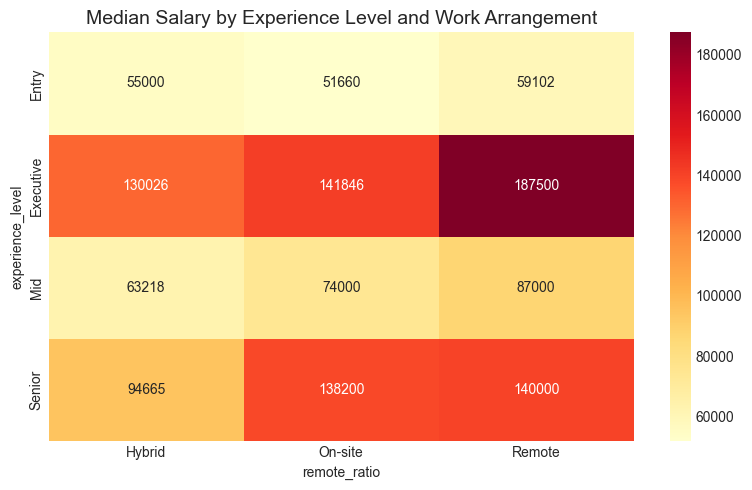

In [19]:
# Cell 13 — Bonus: experience level vs remote work heatmap
# How do salary levels vary across experience and work arrangement combined?
plt.figure(figsize=(8, 5))

pivot = df.pivot_table(values="salary_in_usd",
                       index="experience_level",
                       columns="remote_ratio",
                       aggfunc="median")

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Median Salary by Experience Level and Work Arrangement", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
df[df["company_location"] == "RU"].shape[0]

2

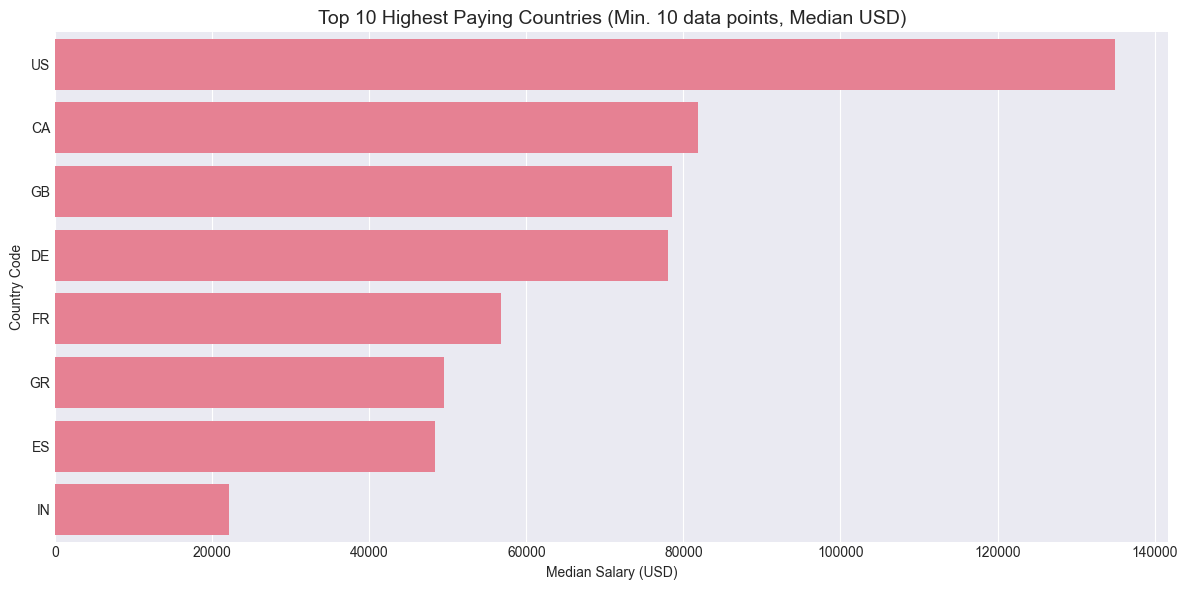

In [22]:
# Cell 15 — Top paying countries with minimum 10 data points
plt.figure(figsize=(12, 6))

country_counts = df["company_location"].value_counts()
valid_countries = country_counts[country_counts >= 10].index

top_countries_filtered = (df[df["company_location"].isin(valid_countries)]
                           .groupby("company_location")["salary_in_usd"]
                           .median()
                           .sort_values(ascending=False)
                           .head(10))

sns.barplot(x=top_countries_filtered.values, y=top_countries_filtered.index)
plt.title("Top 10 Highest Paying Countries (Min. 10 data points, Median USD)", fontsize=14)
plt.xlabel("Median Salary (USD)")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()

## Key Findings

1. **Top paying roles are lead and domain-specialized positions** — Data Analytics Lead 
and Financial Data Analyst outperform pure technical titles like Data Scientist, 
suggesting business impact commands a premium over technical skill alone.

2. **Experience level has the biggest impact on salary** — Executive roles earn 
significantly more than entry level, but senior roles show the widest spread, 
meaning company and location choice matters more at senior levels.

3. **Remote work pays slightly more than on-site** — The combination of Executive 
experience and remote work arrangement produces the highest median salaries.

4. **Salaries are trending upward** — Median compensation grew from 2020 to 2022, 
reflecting increased demand for AI/data science talent.

5. **The US dominates global compensation** — After filtering for statistical validity 
(minimum 10 data points per country), the US clearly leads global AI salaries.

6. **Small sample sizes mislead** — Russia initially appeared highest paying but 
represented only 2 data points. Always validate sample sizes before drawing conclusions.